In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering, MiniBatchKMeans, Birch, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.utils import resample
from scipy.cluster.hierarchy import linkage, dendrogram
import faiss
import time
import hdbscan

In [2]:
def plot_clusters_pca(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [3]:
def plot_clusters(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [4]:
def metrike(title,X,labels):
    print("Silhouette +",title,":", silhouette_score(X, labels))
    print("Davies-Bouldin indeks: +",title,":", davies_bouldin_score(X, labels))

In [5]:
def metrike1(iter,X,labels):
    return {
        "iter:": iter,
        "Silhouette": round(silhouette_score(X, labels), 3),
        "Davies-Bouldin indeks": round(davies_bouldin_score(X, labels), 3),
    }

In [6]:
def toExel(exel, title):
    df_exel = pd.DataFrame(exel)
    df_exel.to_excel(f"rezKlasterCLICK2/{title}.xlsx", index=False)

In [7]:
def cluster1(model, title, X, iter):
    start = time.perf_counter()
    model.fit(X)
    

    labels = model.labels_
    end = time.perf_counter()
    trajanje = end - start
    met = metrike1(iter, X, labels)
    end1 = time.perf_counter()
    trajanje1 = end1 - start

    met['vrijeme trajanja'] = trajanje
    met['vrijeme trajanja1'] = trajanje1
    print(met)
    print(f"{title} | fit trajao: {trajanje:.4f} s")
    print("*"*50)
    return met

In [8]:
def cluster2(model, title, X, iter):
    start = time.perf_counter()
    model.fit_predict(X)
    

    labels = model.labels_
    end = time.perf_counter()
    trajanje = end - start
    met = metrike1(iter, X, labels)
    end1 = time.perf_counter()
    trajanje1 = end1 - start


    met['vrijeme trajanja'] = trajanje
    met['vrijeme trajanja1'] = trajanje1
    print(met)
    print(f"{title} | fit trajao: {trajanje:.4f} s")
    print("*"*50)
    return met

In [9]:
def faisscluster(title, X, i):
    start = time.perf_counter()

    faiss_kmeans = faiss.Kmeans(d=X.shape[1], k=i)
    faiss_kmeans.train(X)

    D, I = faiss_kmeans.index.search(X, 1)
    labels_faiss = I.flatten()

    end = time.perf_counter()
    trajanje = end - start
    met = metrike1(iter, X, labels_faiss)
    end1 = time.perf_counter()
    trajanje1 = end1 - start


    met['vrijeme trajanja'] = trajanje
    met['vrijeme trajanja1'] = trajanje1
    print(met)
    print(f"{title} | fit trajao: {trajanje:.4f} s")
    print("*"*50)
    return met

In [10]:
def mode_func(x):
    return x.mode().iloc[0] if not x.mode().empty else x.iloc[0]

In [11]:
df = pd.read_csv(r'podaci\clickstream+data+for+online+shopping\e-shop clothing 2008 preprocessed.csv', encoding='cp1252', sep=',')
print(df.columns)

Index(['year', 'month', 'day', 'order', 'country', 'session ID',
       'main category', 'clothing model', 'colour', 'location',
       'model photography', 'price', 'price 2', 'page'],
      dtype='object')


In [12]:
session_df = df.groupby("session ID").agg({
    "month": mode_func,
    "day": mode_func,
    "order": "count",   
    "page": ["nunique", "max"],
    "country": mode_func,
    "main category": [mode_func, "nunique"],
    "clothing model": [mode_func, "nunique"],
    "colour": [mode_func, "nunique"],
    "location": [mode_func, "nunique"],
    "model photography": [mode_func, "nunique"],
    "price": ["mean", "max", "min"],
    "price 2": ["mean", "max", "min"]
})

In [13]:
session_df.columns = ["_".join(col) for col in session_df.columns]
session_df = session_df.reset_index()

In [14]:
session_df.head()

,session ID,month_mode_func,day_mode_func,order_count,page_nunique,page_max,country_mode_func,main category_mode_func,main category_nunique,clothing model_mode_func,...,location_mode_func,location_nunique,model photography_mode_func,model photography_nunique,price_mean,price_max,price_min,price 2_mean,price 2_max,price 2_min
0,1,4,1,9,3,5,29,2,4,4,...,1,6,2,2,42.111111,57,28,1.444444,2,1
1,2,4,1,10,2,2,29,2,3,1,...,1,6,1,2,50.000000,67,38,1.200000,2,1
2,3,4,1,6,2,5,21,3,3,51,...,2,4,1,2,42.166667,48,28,1.333333,2,1
3,4,4,1,4,3,3,21,1,2,27,...,1,4,1,1,45.250000,62,33,1.500000,2,1
4,5,4,1,1,1,2,9,3,1,89,...,1,1,1,1,57.000000,57,57,1.000000,1,1


In [15]:
X = session_df.drop("session ID", axis=1)

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

KLASTERI

In [19]:
exel=[]

In [102]:
for i in range(2,6):
    mb_kmeans = MiniBatchKMeans(n_clusters=i, random_state=123)
    
    print("---------------- Broj klastera ",i,"--------------------")
    
    metrika = cluster1(mb_kmeans,"MiniBatchKMeans_X",X,i)
    # metrika = cluster1(mb_kmeans,"MiniBatchKMeans_X_pca",X_pca,i)
    exel.append(metrika)
toExel(exel,'MiniBatchKMeans_X')

---------------- Broj klastera  2 --------------------
{'iter:': 2, 'Silhouette': np.float64(0.527), 'Davies-Bouldin indeks': np.float64(0.703), 'vrijeme trajanja': 0.21920629998203367, 'vrijeme trajanja1': 9.117633200017735}
MiniBatchKMeans_X | fit trajao: 0.2192 s
**************************************************
---------------- Broj klastera  3 --------------------
{'iter:': 3, 'Silhouette': np.float64(0.396), 'Davies-Bouldin indeks': np.float64(0.916), 'vrijeme trajanja': 0.05835249996744096, 'vrijeme trajanja1': 8.381286399962846}
MiniBatchKMeans_X | fit trajao: 0.0584 s
**************************************************
---------------- Broj klastera  4 --------------------
{'iter:': 4, 'Silhouette': np.float64(0.323), 'Davies-Bouldin indeks': np.float64(1.046), 'vrijeme trajanja': 0.05876529996749014, 'vrijeme trajanja1': 8.056272399961017}
MiniBatchKMeans_X | fit trajao: 0.0588 s
**************************************************
---------------- Broj klastera  5 ------------

In [103]:
exel=[]

In [104]:
for i in range(2,6):
    kmeans = KMeans(n_clusters=i , init='k-means++', random_state=123)
    
    print("---------------- Broj klastera ",i,"--------------------")

    metrika = cluster2(kmeans,"KMeans_X",X,i)
    # metrika = cluster2(kmeans,"KMeans_X_pca",X_pca,i)
    exel.append(metrika)
toExel(exel,'KMeans_X')

---------------- Broj klastera  2 --------------------


{'iter:': 2, 'Silhouette': np.float64(0.515), 'Davies-Bouldin indeks': np.float64(0.741), 'vrijeme trajanja': 0.02130559994839132, 'vrijeme trajanja1': 7.3396488999715075}
KMeans_X | fit trajao: 0.0213 s
**************************************************
---------------- Broj klastera  3 --------------------
{'iter:': 3, 'Silhouette': np.float64(0.377), 'Davies-Bouldin indeks': np.float64(0.953), 'vrijeme trajanja': 0.023112500028219074, 'vrijeme trajanja1': 8.607202699990012}
KMeans_X | fit trajao: 0.0231 s
**************************************************
---------------- Broj klastera  4 --------------------
{'iter:': 4, 'Silhouette': np.float64(0.312), 'Davies-Bouldin indeks': np.float64(1.138), 'vrijeme trajanja': 0.02300799998920411, 'vrijeme trajanja1': 8.484930099977646}
KMeans_X | fit trajao: 0.0230 s
**************************************************
---------------- Broj klastera  5 --------------------
{'iter:': 5, 'Silhouette': np.float64(0.292), 'Davies-Bouldin indeks': 

In [105]:
exel = []

In [106]:
for i in range(2,6):
    metrika = faisscluster("Faiss_X", X, i)
    # metrika = faisscluster("Faiss_X_pca", X_pca, i)
    exel.append(metrika)
toExel(exel,'Faiss_X')

{'iter:': <built-in function iter>, 'Silhouette': np.float64(0.516), 'Davies-Bouldin indeks': np.float64(0.74), 'vrijeme trajanja': 0.021390700014308095, 'vrijeme trajanja1': 9.248427400016226}
Faiss_X | fit trajao: 0.0214 s
**************************************************
{'iter:': <built-in function iter>, 'Silhouette': np.float64(0.376), 'Davies-Bouldin indeks': np.float64(0.955), 'vrijeme trajanja': 0.020113800012040883, 'vrijeme trajanja1': 7.157048099965323}
Faiss_X | fit trajao: 0.0201 s
**************************************************
{'iter:': <built-in function iter>, 'Silhouette': np.float64(0.313), 'Davies-Bouldin indeks': np.float64(1.137), 'vrijeme trajanja': 0.02496509999036789, 'vrijeme trajanja1': 8.679541999998037}
Faiss_X | fit trajao: 0.0250 s
**************************************************
{'iter:': <built-in function iter>, 'Silhouette': np.float64(0.247), 'Davies-Bouldin indeks': np.float64(1.348), 'vrijeme trajanja': 0.020457500009797513, 'vrijeme trajanj

In [108]:
exel = []

In [109]:
for i in range(2,6):
    spectral = SpectralClustering(n_clusters=i, affinity='nearest_neighbors', random_state=123)

    print("---------------- Broj klastera ",i,"--------------------")

    metrika = cluster2(spectral,"Spectral_X",X,i)
    # metrika = cluster2(spectral,"Spectral_X_PCA",X_pca, i)
    exel.append(metrika)
toExel(exel,'Spectral_X')

---------------- Broj klastera  2 --------------------


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'iter:': 2, 'Silhouette': np.float64(0.178), 'Davies-Bouldin indeks': np.float64(0.926), 'vrijeme trajanja': 31.317798500007484, 'vrijeme trajanja1': 39.57519289996708}
Spectral_X | fit trajao: 31.3178 s
**************************************************
---------------- Broj klastera  3 --------------------


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'iter:': 3, 'Silhouette': np.float64(0.36), 'Davies-Bouldin indeks': np.float64(0.702), 'vrijeme trajanja': 27.1878987000091, 'vrijeme trajanja1': 35.588552100001834}
Spectral_X | fit trajao: 27.1879 s
**************************************************
---------------- Broj klastera  4 --------------------


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'iter:': 4, 'Silhouette': np.float64(0.351), 'Davies-Bouldin indeks': np.float64(0.863), 'vrijeme trajanja': 24.4994885000051, 'vrijeme trajanja1': 32.444973700039554}
Spectral_X | fit trajao: 24.4995 s
**************************************************
---------------- Broj klastera  5 --------------------


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'iter:': 5, 'Silhouette': np.float64(0.273), 'Davies-Bouldin indeks': np.float64(0.893), 'vrijeme trajanja': 24.46885000000475, 'vrijeme trajanja1': 32.21110169996973}
Spectral_X | fit trajao: 24.4689 s
**************************************************


In [110]:
exel = []

In [111]:
for i in range(2,6):
    agg = AgglomerativeClustering(n_clusters=i)

    print("---------------- Broj klastera ",i,"--------------------")

    metrika = cluster2(agg,"AGG_X",X,i)
    # metrika = cluster2(agg,"AGG_X_PCA",X_pca,i)
    exel.append(metrika)
toExel(exel,'AGG_X')

---------------- Broj klastera  2 --------------------
{'iter:': 2, 'Silhouette': np.float64(0.538), 'Davies-Bouldin indeks': np.float64(0.611), 'vrijeme trajanja': 21.412567500025034, 'vrijeme trajanja1': 30.242702100018505}
AGG_X | fit trajao: 21.4126 s
**************************************************
---------------- Broj klastera  3 --------------------
{'iter:': 3, 'Silhouette': np.float64(0.333), 'Davies-Bouldin indeks': np.float64(0.974), 'vrijeme trajanja': 21.505093099956866, 'vrijeme trajanja1': 29.512496699986514}
AGG_X | fit trajao: 21.5051 s
**************************************************
---------------- Broj klastera  4 --------------------
{'iter:': 4, 'Silhouette': np.float64(0.273), 'Davies-Bouldin indeks': np.float64(1.185), 'vrijeme trajanja': 21.510603600007016, 'vrijeme trajanja1': 29.462816099985503}
AGG_X | fit trajao: 21.5106 s
**************************************************
---------------- Broj klastera  5 --------------------
{'iter:': 5, 'Silhouette

In [1]:
exel = []

In [20]:
for i in range(2,6):
    birch = Birch(n_clusters=i)
    
    print("---------------- Broj klastera ",i,"--------------------")
    
    metrika = cluster1(birch,"Birch_X",X,i)
    # metrika = cluster1(birch,"Birch_X_pca",X_pca,i)
    exel.append(metrika)
toExel(exel,'Birch_X')

---------------- Broj klastera  2 --------------------
{'iter:': 2, 'Silhouette': np.float64(0.545), 'Davies-Bouldin indeks': np.float64(0.642), 'vrijeme trajanja': 20.522393999970518, 'vrijeme trajanja1': 29.899539800011553}
Birch_X | fit trajao: 20.5224 s
**************************************************
---------------- Broj klastera  3 --------------------
{'iter:': 3, 'Silhouette': np.float64(0.338), 'Davies-Bouldin indeks': np.float64(1.0), 'vrijeme trajanja': 20.753874100046232, 'vrijeme trajanja1': 28.969305700040422}
Birch_X | fit trajao: 20.7539 s
**************************************************
---------------- Broj klastera  4 --------------------
{'iter:': 4, 'Silhouette': np.float64(0.25), 'Davies-Bouldin indeks': np.float64(1.264), 'vrijeme trajanja': 22.017736999958288, 'vrijeme trajanja1': 29.890899699996226}
Birch_X | fit trajao: 22.0177 s
**************************************************
---------------- Broj klastera  5 --------------------
{'iter:': 5, 'Silhoue

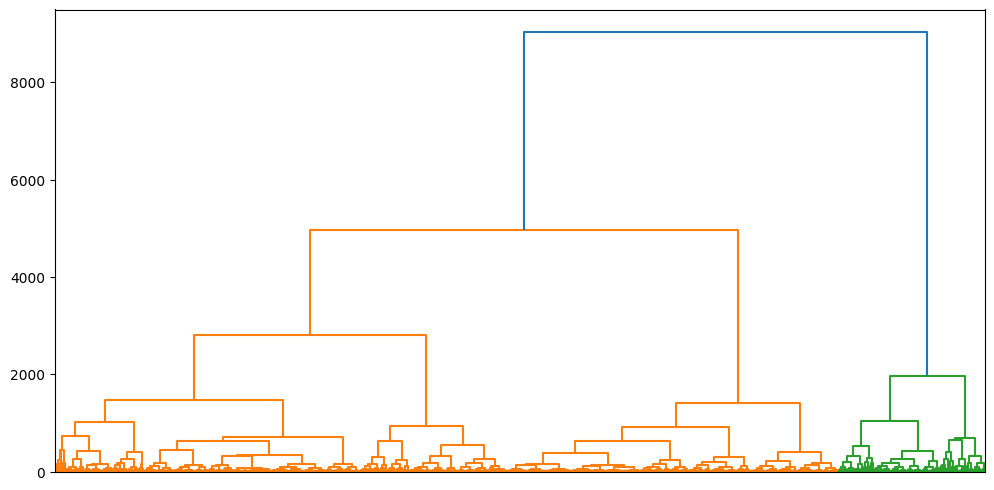

In [18]:

linked = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False, no_labels=True)
plt.show()